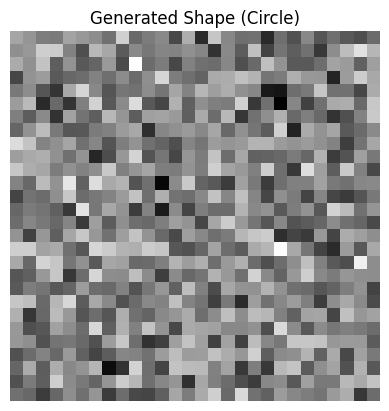

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# Parameters
latent_dim = 10
num_classes = 2   # circle, square
img_size = 28

# Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        
        self.model = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 128),
            nn.ReLU(),
            nn.Linear(128, img_size * img_size),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        c = self.label_emb(labels)
        x = torch.cat([noise, c], dim=1)
        return self.model(x)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)

        self.model = nn.Sequential(
            nn.Linear(img_size * img_size + num_classes, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        c = self.label_emb(labels)
        x = torch.cat([img, c], dim=1)
        return self.model(x)

# Initialize
G = Generator()
D = Discriminator()

# Sample generation (no full training for simplicity)
noise = torch.randn(1, latent_dim)
label_circle = torch.tensor([0])  # 0 = circle

generated = G(noise, label_circle).detach().numpy().reshape(28,28)

plt.imshow(generated, cmap="gray")
plt.title("Generated Shape (Circle)")
plt.axis("off")
plt.show()